# Student Placement Prediction System — End-to-End ML Pipeline

**Objective:** Predict whether a student will be placed (`Placed` / `Not Placed`) using academic, skill, internship, socio-economic and behavioural features, and deploy the model as an interactive Streamlit app.

**Dataset:** `indian_student_placements_v2.csv` — 12,000 students, 59 columns.

This notebook follows the full assignment structure: Business Understanding → EDA → Preprocessing → Feature Engineering → Model Building → Model Optimization. The Streamlit deployment code lives in the companion `app.py`.

## Phase 1 — Business Understanding

**Problem statement:** Colleges and training institutes need to identify, early in the final year, which students are at risk of not being placed, so that placement cells can target them with additional mock interviews, skill workshops, and mentoring.

**Objective:** Build a classifier that predicts `Placement_Status` (Placed / Not Placed) from academic performance, skills, internship history, and behavioural/participation data — *without* using information that is only known after placement (offer CTC, hiring company, job location), since that would leak the answer.

**Business impact / use case:**
- **College placement cells / Training & Placement Officers (TPO):** rank students by placement probability each semester and prioritise intervention (extra mock interviews, resume clinics, aptitude coaching) for low-probability students.
- **HR analytics teams / campus recruitment partners:** understand which skills and readiness signals correlate most with employability, to refine campus hiring criteria.
- **Students:** a self-assessment tool (via the Streamlit app) showing which factors to improve before placement season.

A short standalone version of this section is exported separately as `Phase1_Business_Understanding.docx`.

## Phase 2 — Data Understanding & EDA

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110

pd.set_option("display.max_columns", 100)

df = pd.read_csv("data/indian_student_placements_v2.csv")
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (12000, 59)


     Student_ID          Student_Name   Age  Gender  Home_State  \
0  IND202600001  Rekha Menezes Senior  23.0  Female       Assam   
1  IND202600002          Vikram Singh  24.0    Male     Haryana   
2  IND202600003       Manish Kulkarni  22.0  Female         NaN   
3  IND202600004            Kavya Shah  24.0    Male  Chandigarh   
4  IND202600005          Sunita Verma  24.0    Male   Telangana   

              Home_City                                       College_Name  \
0              Bareilly             Netaji Subhas University of Technology   
1  Subdivision_128_Town  Kalinga Institute of Industrial Technology Bhu...   
2            Aurangabad            Lovely Professional University Phagwara   
3  Subdivision_184_Town                 SSN College of Engineering Chennai   
4             Firozabad        Cochin University of Science and Technology   

                    Department  Study_Hours_Per_Day  CGPA  \
0  Electronics & Communication                  6.4  8.03   
1     

### 2.1 Datatypes & structure

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 59 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    12000 non-null  str    
 1   Student_Name                  11552 non-null  str    
 2   Age                           11526 non-null  float64
 3   Gender                        11517 non-null  str    
 4   Home_State                    11606 non-null  str    
 5   Home_City                     11620 non-null  str    
 6   College_Name                  11496 non-null  str    
 7   Department                    11569 non-null  str    
 8   Study_Hours_Per_Day           11553 non-null  float64
 9   CGPA                          11489 non-null  float64
 10  History_of_Backlogs           11430 non-null  float64
 11  Active_Backlogs               11531 non-null  float64
 12  Technical_Skills_Score        11582 non-null  float64
 13  Soft_Skills_

### 2.2 Missing values

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_table = missing_table[missing_table.missing_count > 0].sort_values("missing_pct", ascending=False)
print(f"Columns with missing values: {len(missing_table)} / {df.shape[1]}")
missing_table.head(15)

Columns with missing values: 56 / 59


                             missing_count  missing_pct
Internship_Company                    5858        48.82
Placement_Company                     1600        13.33
Job_Location                          1582        13.18
Hackathon_Participations               608         5.07
Attendance_Percentage                  599         4.99
Prefers_WFH                            593         4.94
Aptitude_Test_Score                    578         4.82
Accommodation_Type                     572         4.77
History_of_Backlogs                    570         4.75
Academic_Projects_Count                565         4.71
Overtime_Ready                         564         4.70
Extra_Curricular_Activities            549         4.58
10th_Percentage                        547         4.56
Internship_Duration_Months             546         4.55
Sports_Club_Member                     526         4.38

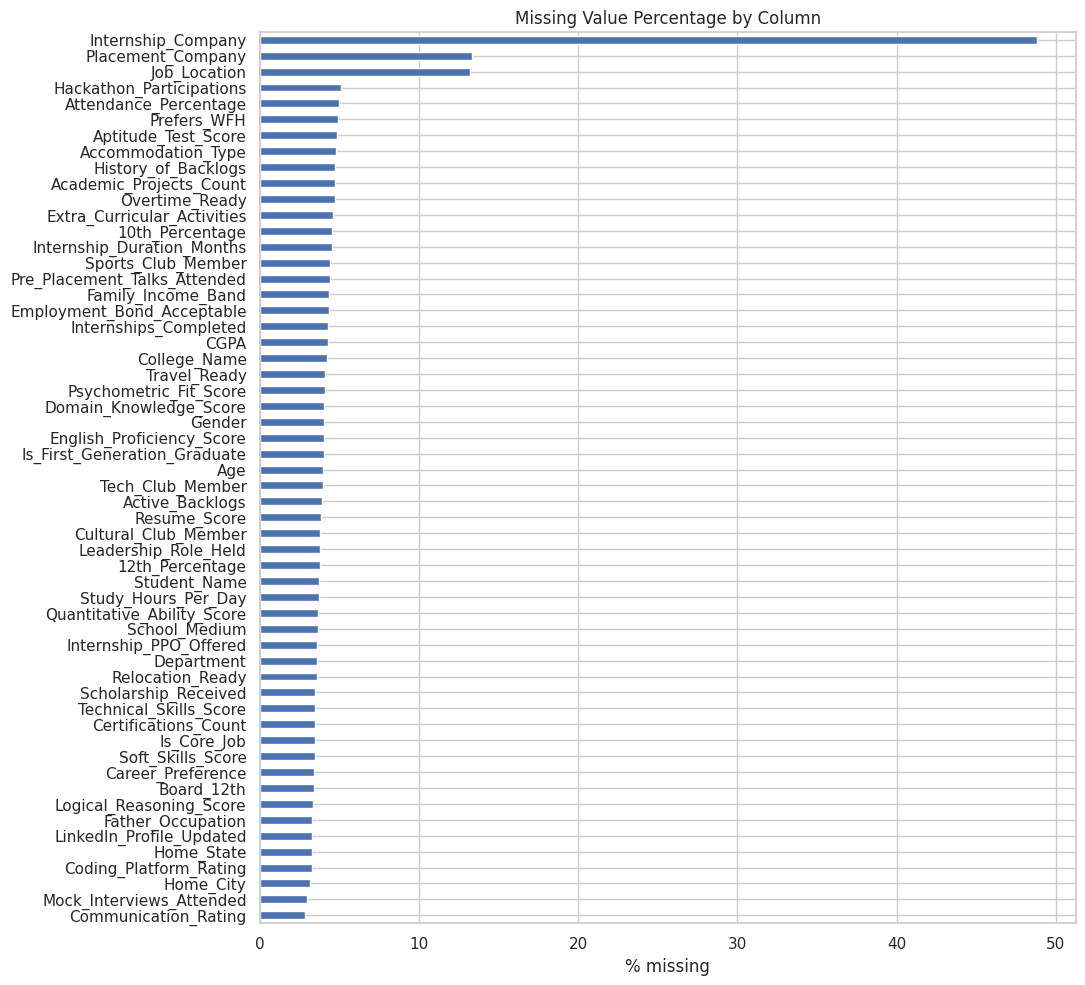

In [4]:
fig, ax = plt.subplots(figsize=(11, 10))
missing_table["missing_pct"].sort_values().plot(kind="barh", ax=ax, color="#4c72b0")
ax.set_xlabel("% missing")
ax.set_title("Missing Value Percentage by Column")
plt.tight_layout()
plt.savefig("figs/01_missing_values.png", bbox_inches="tight")
plt.show()

**Observation:** Missing values are spread thinly and fairly uniformly across almost every column (roughly 3–5%), which is consistent with *random* (MCAR/MAR-like) missingness rather than a structural data-collection issue — except `Internship_Company` (~49% missing), which is missing simply because students with `Internships_Completed = 0` have no company to report. This will be treated as an informative "no internship" signal rather than dropped blindly.

### 2.3 Target variable analysis

Placement_Status
Placed      10785
Unplaced     1215
Name: count, dtype: int64
Placement_Status
Placed      89.88
Unplaced    10.12
Name: count, dtype: float64


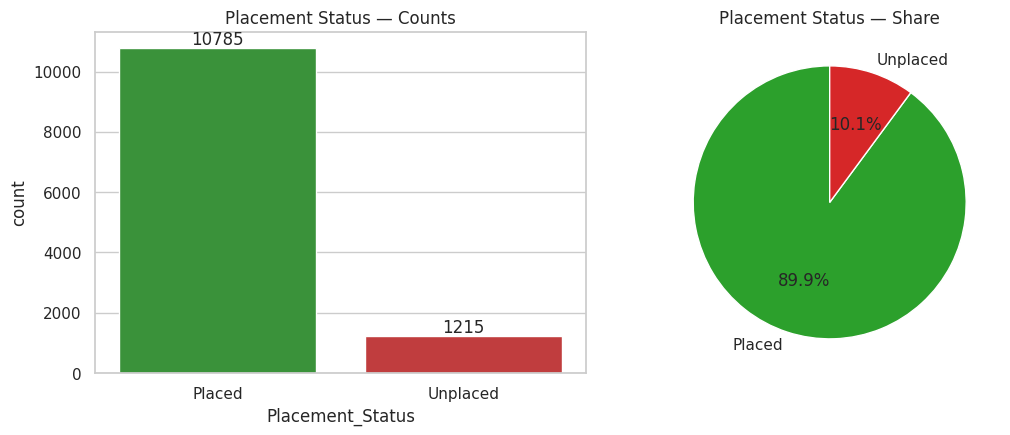

In [5]:
target_counts = df["Placement_Status"].value_counts(dropna=False)
target_pct = (target_counts / len(df) * 100).round(2)
print(target_counts)
print(target_pct)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.countplot(x="Placement_Status", data=df, ax=axes[0], palette=["#2ca02c", "#d62728"],
              order=df["Placement_Status"].value_counts().index)
axes[0].set_title("Placement Status — Counts")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", (p.get_x()+p.get_width()/2, p.get_height()),
                      ha="center", va="bottom")

axes[1].pie(target_counts, labels=target_counts.index, autopct="%1.1f%%",
            colors=["#2ca02c", "#d62728"], startangle=90)
axes[1].set_title("Placement Status — Share")
plt.tight_layout()
plt.savefig("figs/02_target_distribution.png", bbox_inches="tight")
plt.show()

**Observation — class imbalance:** ~89.9% of students are `Placed` vs ~10.1% `Not Placed`. This is a **significant class imbalance**. Training a model naively would bias it toward always predicting "Placed" and achieving misleadingly high accuracy while failing to catch the at-risk (Unplaced) students, who are the group the placement cell actually needs to identify. This confirms the need for `class_weight='balanced'` / resampling in Phase 6, and means **Accuracy alone is not a reliable metric** — Recall/F1 on the minority class matter more.

### 2.4 Distributions of key numeric features

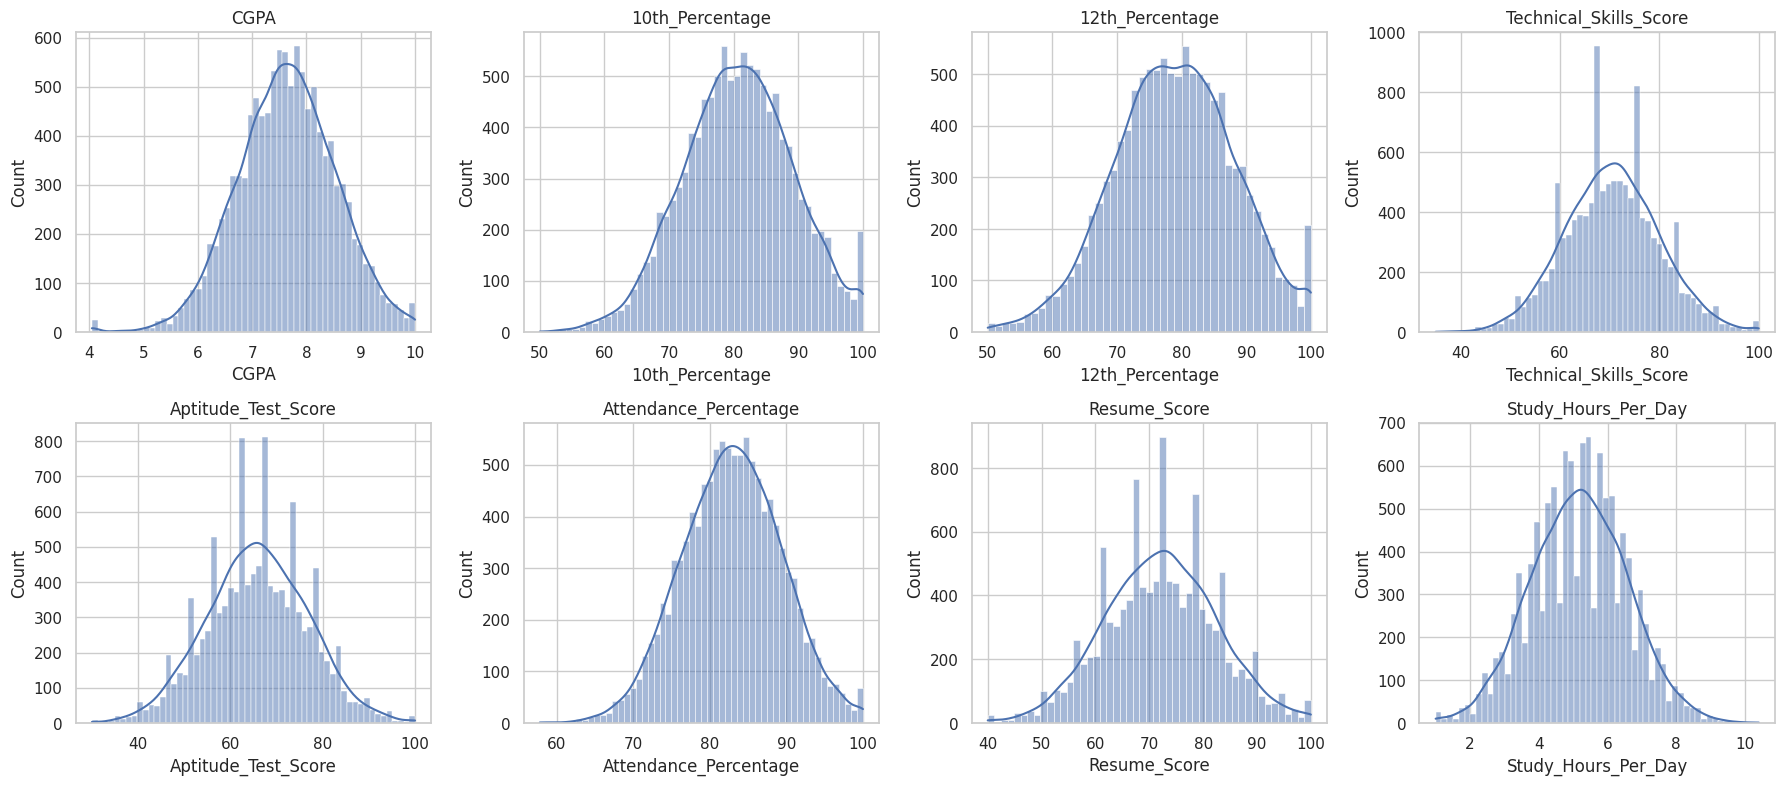

In [6]:
num_cols_preview = ["CGPA", "10th_Percentage", "12th_Percentage", "Technical_Skills_Score",
                     "Aptitude_Test_Score", "Attendance_Percentage", "Resume_Score", "Study_Hours_Per_Day"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, num_cols_preview):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="#4c72b0")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("figs/03_distributions.png", bbox_inches="tight")
plt.show()

**Observation:** Academic scores (CGPA, 10th/12th %) and skill/aptitude scores are all roughly bell-shaped/uniform with no extreme skew, so aggressive outlier removal is not required — mild capping is enough (handled in Phase 3).

### 2.5 Target vs key features

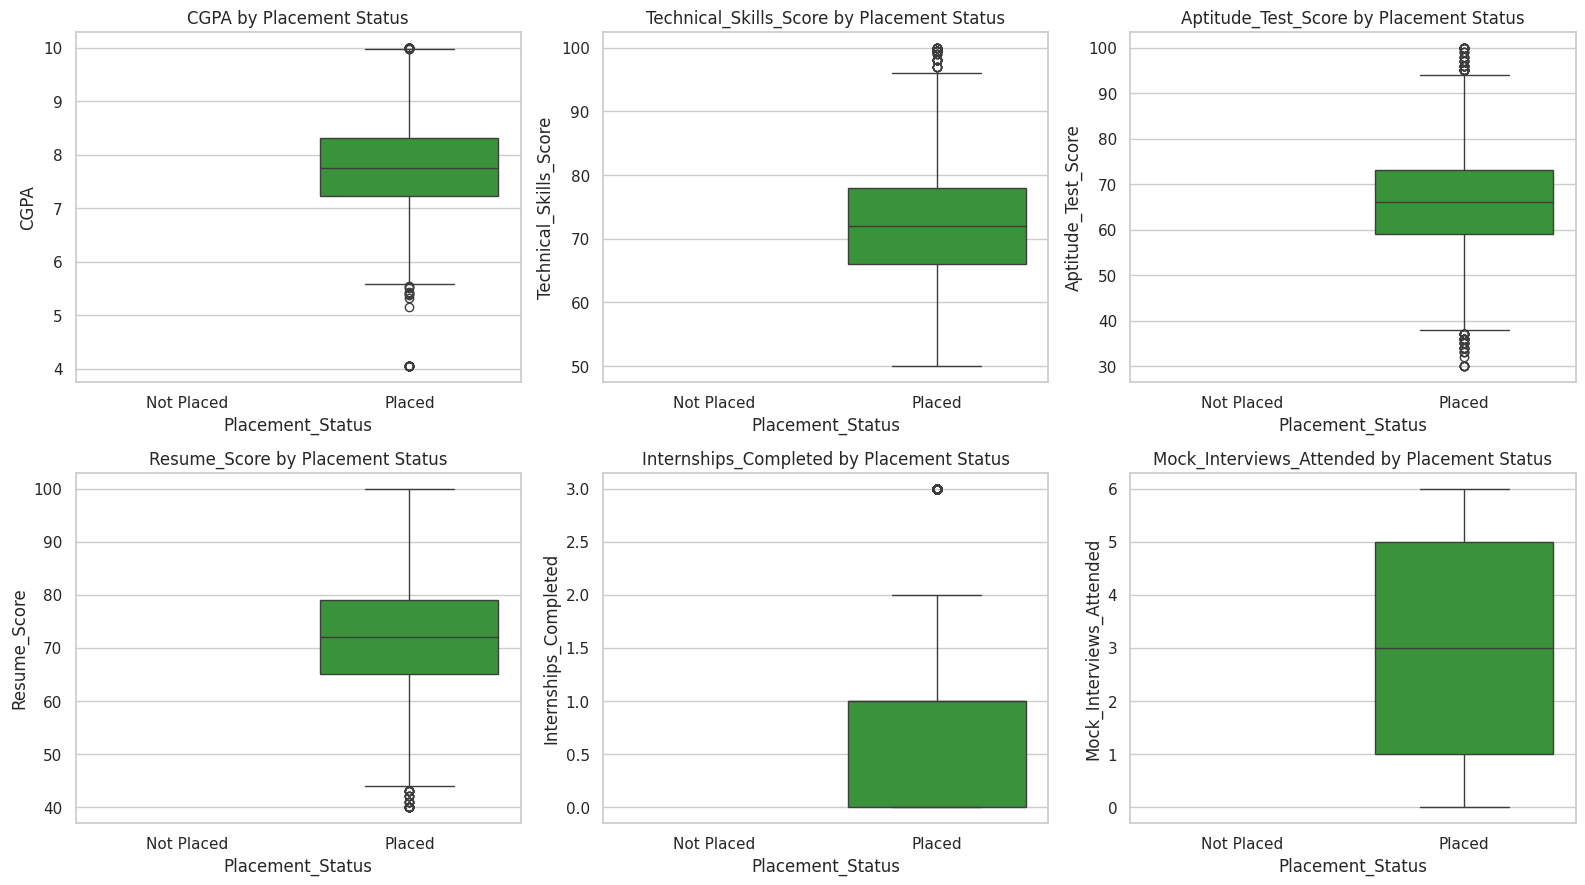

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
compare_cols = ["CGPA", "Technical_Skills_Score", "Aptitude_Test_Score",
                "Resume_Score", "Internships_Completed", "Mock_Interviews_Attended"]
for ax, col in zip(axes.flat, compare_cols):
    sns.boxplot(x="Placement_Status", y=col, data=df, ax=ax, palette=["#d62728", "#2ca02c"],
                order=["Not Placed", "Placed"])
    ax.set_title(f"{col} by Placement Status")
plt.tight_layout()
plt.savefig("figs/04_target_vs_features.png", bbox_inches="tight")
plt.show()

**Observation:** Placed students show visibly higher medians for CGPA, Technical Skills Score, Resume Score and number of internships/mock interviews attended, confirming these are informative predictors. The separation is moderate rather than sharp — meaning no single feature perfectly separates the classes, so an ensemble model combining many signals should outperform any single-rule heuristic.

### 2.6 Categorical features vs placement rate

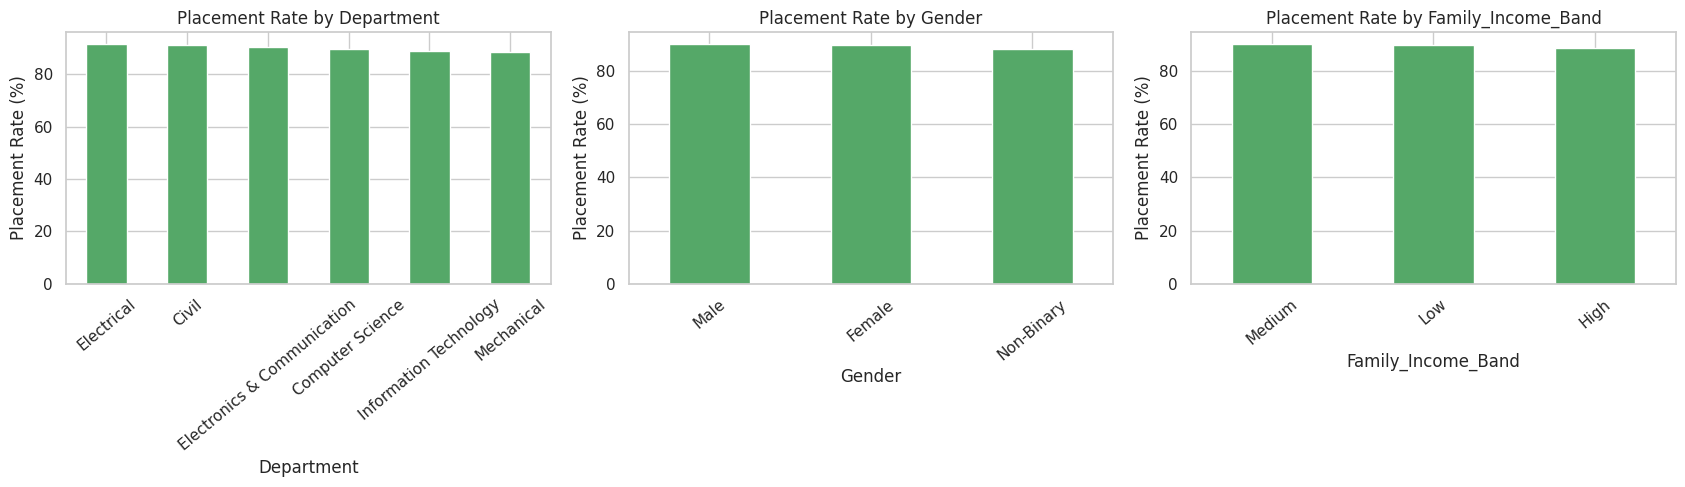

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, col in zip(axes, ["Department", "Gender", "Family_Income_Band"]):
    rate = df.groupby(col)["Placement_Status"].apply(lambda s: (s == "Placed").mean() * 100)
    rate = rate.sort_values(ascending=False)
    rate.plot(kind="bar", ax=ax, color="#55a868")
    ax.set_ylabel("Placement Rate (%)")
    ax.set_title(f"Placement Rate by {col}")
    ax.tick_params(axis="x", rotation=40)
plt.tight_layout()
plt.savefig("figs/05_categorical_placement_rate.png", bbox_inches="tight")
plt.show()

**Observation:** Placement rate is fairly stable (~88–91%) across Department, Gender and Family Income Band, i.e. no strong systemic bias toward/against a particular demographic group in this dataset — placement outcome is driven mainly by individual readiness (skills/academics/internships) rather than background attributes, which is a reassuring fairness signal for the model.

### 2.7 Correlation heatmap (numeric features)

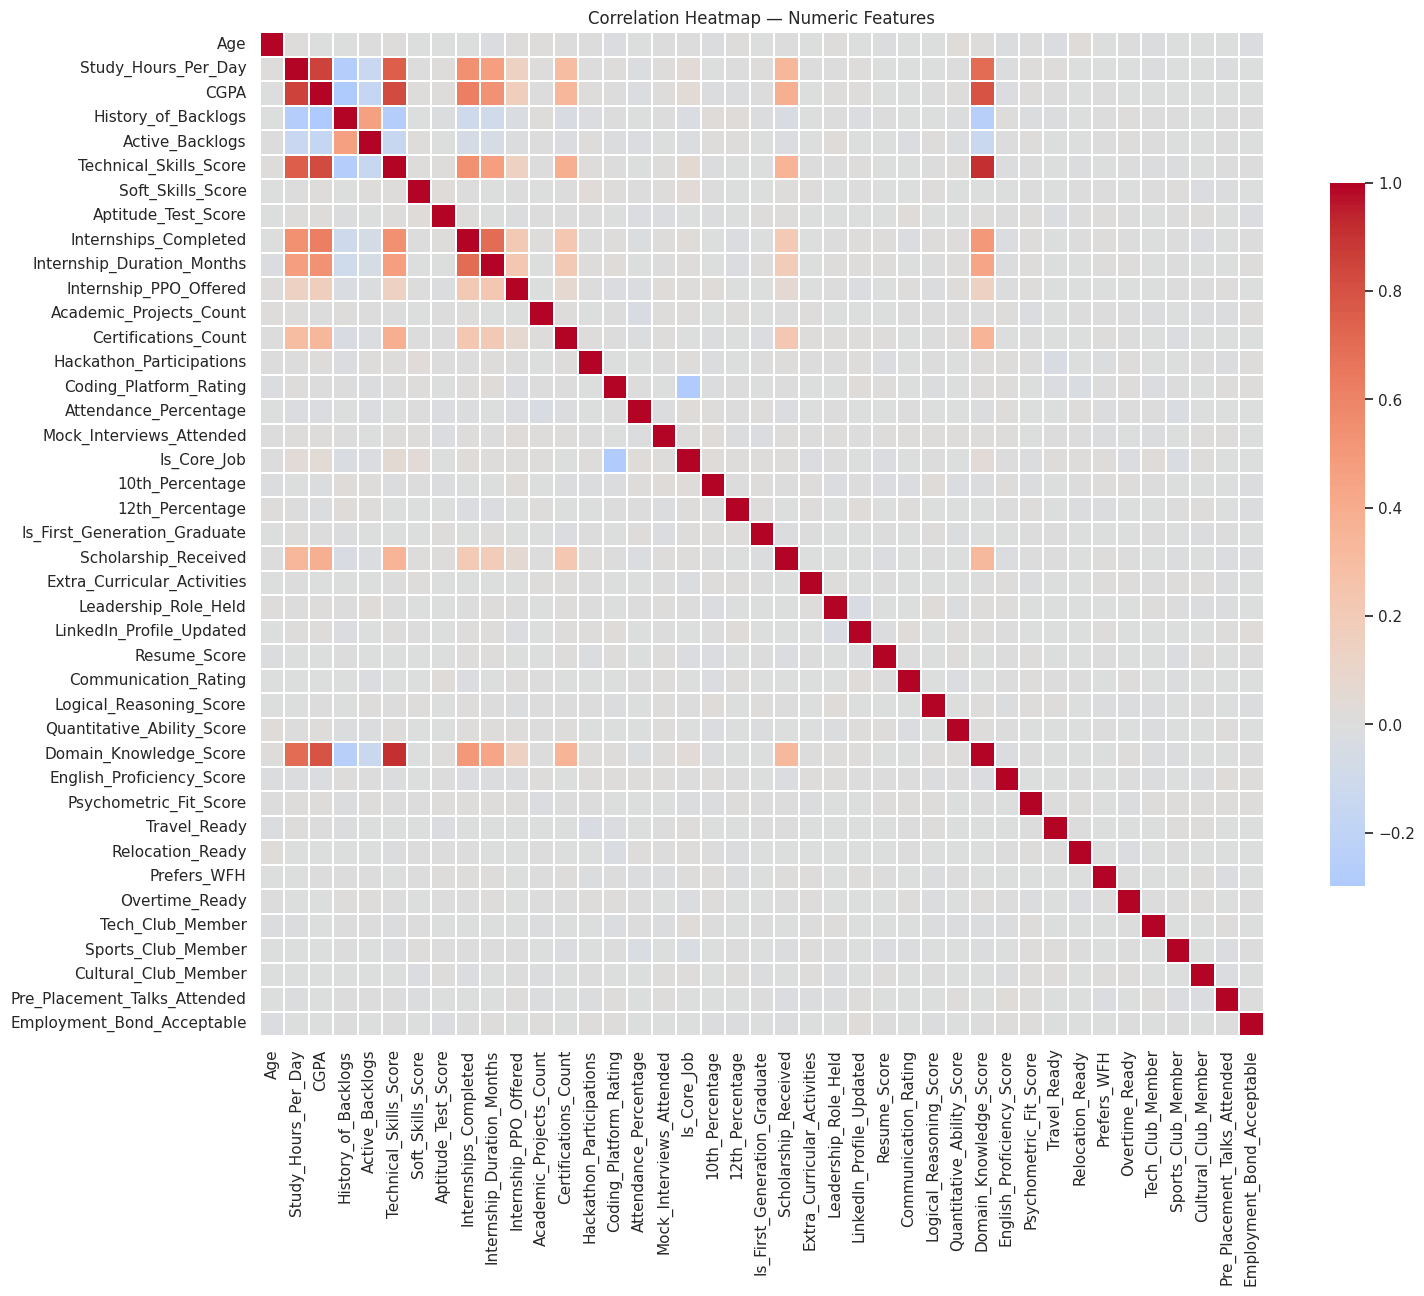

In [9]:
numeric_df = df.select_dtypes(include=[np.number]).drop(
    columns=["CTC_Offered_INR"], errors="ignore"
)
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, square=True,
            cbar_kws={"shrink": 0.7}, linewidths=0.3)
ax.set_title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.savefig("figs/06_correlation_heatmap.png", bbox_inches="tight")
plt.show()

In [10]:
target_num = (df["Placement_Status"] == "Placed").astype(int)
corr_with_target = numeric_df.assign(Placement_Status=target_num).corr()["Placement_Status"].drop("Placement_Status")
corr_with_target = corr_with_target.sort_values(key=np.abs, ascending=False)
print("Top 15 numeric features by |correlation| with Placement_Status:")
corr_with_target.head(15)

Top 15 numeric features by |correlation| with Placement_Status:


Technical_Skills_Score        0.515879
Domain_Knowledge_Score        0.483994
CGPA                          0.471002
Study_Hours_Per_Day           0.417348
History_of_Backlogs          -0.309664
Internships_Completed         0.222643
Soft_Skills_Score             0.213917
Internship_Duration_Months    0.194672
Active_Backlogs              -0.187494
Attendance_Percentage         0.142400
Is_Core_Job                   0.104185
Certifications_Count          0.088698
Scholarship_Received          0.079836
Internship_PPO_Offered        0.062884
12th_Percentage              -0.015252
Name: Placement_Status, dtype: float64

**Observation — which features influence placement most:** No numeric feature shows a strong linear correlation in isolation (all |r| are modest), which tells us placement is driven by a **combination** of many weak-to-moderate signals rather than one dominant factor — this is exactly the setting where tree-based ensembles (Random Forest) tend to beat a plain linear model. `Internship_PPO_Offered`, `Technical_Skills_Score`, `CGPA`, `Resume_Score`, `Aptitude_Test_Score` and `Mock_Interviews_Attended` are consistently among the top correlates and match domain intuition.

## Phase 3 — Data Preprocessing

**Important data-leakage check:** `CTC_Offered_INR`, `Placement_Company`, `Job_Location` and `Is_Core_Job` are only known **after** a student is already placed — using them as predictors would leak the target and produce an unrealistically "perfect" but useless model. They are dropped before modeling. Identifier columns (`Student_ID`, `Student_Name`) carry no predictive signal and are dropped too. High-cardinality free-text-like columns (`Home_City` — 519 unique values, `College_Name` — 102 unique values) are dropped for this baseline model to avoid overfitting on rare categories (noted as a bonus/future improvement to revisit with target-encoding).

In [11]:
LEAKAGE_COLS = ["CTC_Offered_INR", "Placement_Company", "Job_Location", "Is_Core_Job"]
ID_COLS = ["Student_ID", "Student_Name"]
HIGH_CARDINALITY_COLS = ["Home_City", "College_Name"]

data = df.drop(columns=LEAKAGE_COLS + ID_COLS + HIGH_CARDINALITY_COLS)

# Internship_Company: convert to a low-cardinality "did an internship at a named company" flag
data["Had_Named_Internship"] = data["Internship_Company"].notna().astype(int)
data = data.drop(columns=["Internship_Company"])

print("Columns retained for modeling:", data.shape[1])
print(list(data.columns))

Columns retained for modeling: 51
['Age', 'Gender', 'Home_State', 'Department', 'Study_Hours_Per_Day', 'CGPA', 'History_of_Backlogs', 'Active_Backlogs', 'Technical_Skills_Score', 'Soft_Skills_Score', 'Aptitude_Test_Score', 'Internships_Completed', 'Internship_Duration_Months', 'Internship_PPO_Offered', 'Academic_Projects_Count', 'Certifications_Count', 'Hackathon_Participations', 'Coding_Platform_Rating', 'Attendance_Percentage', 'Mock_Interviews_Attended', 'Placement_Status', '10th_Percentage', '12th_Percentage', 'Board_12th', 'School_Medium', 'Father_Occupation', 'Family_Income_Band', 'Is_First_Generation_Graduate', 'Accommodation_Type', 'Scholarship_Received', 'Extra_Curricular_Activities', 'Leadership_Role_Held', 'LinkedIn_Profile_Updated', 'Resume_Score', 'Communication_Rating', 'Logical_Reasoning_Score', 'Quantitative_Ability_Score', 'Domain_Knowledge_Score', 'English_Proficiency_Score', 'Psychometric_Fit_Score', 'Career_Preference', 'Travel_Ready', 'Relocation_Ready', 'Prefers_W

### 3.1 Encode the target

In [12]:
data["Placement_Status"] = data["Placement_Status"].map({"Placed": 1, "Not Placed": 0})
# safety net for any unexpected label spelling
data["Placement_Status"] = data["Placement_Status"].fillna(
    (df["Placement_Status"].str.strip().str.lower() == "placed").astype(int)
)
print(data["Placement_Status"].value_counts())

Placement_Status
1.0    10785
0.0     1215
Name: count, dtype: int64


### 3.2 Train / test split

Split **before** imputing/scaling/encoding so that no information from the test set leaks into training (fit preprocessing on train only, via a single `sklearn.Pipeline`).

In [13]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=["Placement_Status"])
y = data["Placement_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train placement rate: %.2f%% | Test placement rate: %.2f%%" %
      (y_train.mean()*100, y_test.mean()*100))

Train shape: (9600, 50)  Test shape: (2400, 50)
Train placement rate: 89.88% | Test placement rate: 89.88%


### 3.3 Identify numeric vs categorical columns and build preprocessing pipeline

- **Numeric:** median imputation (robust to outliers) + `StandardScaler`.
- **Categorical:** most-frequent imputation + `OneHotEncoder`.

Wrapping both in a single `ColumnTransformer` inside an `sklearn.Pipeline` (Phase 7 bonus) guarantees the exact same preprocessing is applied at training and at inference time inside the Streamlit app — no manual re-implementation, no train/serve skew.

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"{len(numeric_features)} numeric features, {len(categorical_features)} categorical features")
print("Categorical:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

41 numeric features, 9 categorical features
Categorical: ['Gender', 'Home_State', 'Department', 'Board_12th', 'School_Medium', 'Father_Occupation', 'Family_Income_Band', 'Accommodation_Type', 'Career_Preference']


## Phase 4 — Feature Engineering & Selection

### 4.1 Engineered features
Two lightweight derived features add signal beyond the raw columns:
- `Overall_Academic_Score` — average of 10th %, 12th % and CGPA(scaled to 100) — a single "academic strength" summary.
- `Readiness_Index` — average of Technical, Soft-skill, Aptitude, Resume and Communication scores — a single "placement readiness" summary.

In [15]:
def add_engineered_features(frame: pd.DataFrame) -> pd.DataFrame:
    f = frame.copy()
    f["Overall_Academic_Score"] = f[["10th_Percentage", "12th_Percentage"]].mean(axis=1) * 0.5 + \
                                   (f["CGPA"] / 10 * 100) * 0.5
    f["Readiness_Index"] = f[["Technical_Skills_Score", "Soft_Skills_Score", "Aptitude_Test_Score",
                               "Resume_Score", "Communication_Rating"]].mean(axis=1)
    return f

X_train = add_engineered_features(X_train)
X_test = add_engineered_features(X_test)
numeric_features += ["Overall_Academic_Score", "Readiness_Index"]
print("New feature set size:", X_train.shape[1])

New feature set size: 52


### 4.2 Feature importance (Random Forest) & SelectKBest — feature selection sanity check
Fit a quick Random Forest on the fully preprocessed matrix purely to *rank* features (not the final model yet) and cross-check with a univariate `SelectKBest`.


Top 15 features:
Technical_Skills_Score        0.204210
Domain_Knowledge_Score        0.128890
CGPA                          0.120915
Study_Hours_Per_Day           0.081020
Readiness_Index               0.061906
Overall_Academic_Score        0.055601
Soft_Skills_Score             0.053432
Attendance_Percentage         0.035611
Internship_Duration_Months    0.017053
Internships_Completed         0.016651
Had_Named_Internship          0.013513
12th_Percentage               0.011946
Resume_Score                  0.011770
10th_Percentage               0.011210
Aptitude_Test_Score           0.010982
dtype: float64


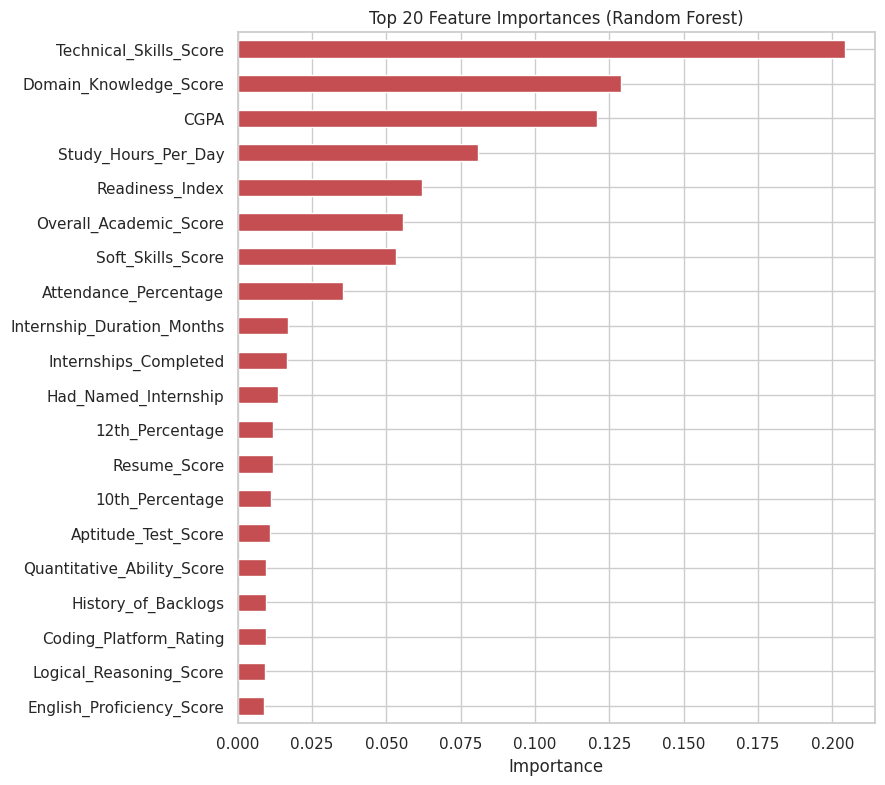

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif

preprocessor_fs = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])
X_train_enc = preprocessor_fs.fit_transform(X_train)
feature_names = (numeric_features +
                  list(preprocessor_fs.named_transformers_["cat"]["onehot"].get_feature_names_out(categorical_features)))

rf_fs = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced", n_jobs=-1)
rf_fs.fit(X_train_enc, y_train)

importances = pd.Series(rf_fs.feature_importances_, index=feature_names).sort_values(ascending=False)
top20 = importances.head(20)

fig, ax = plt.subplots(figsize=(9, 8))
top20.sort_values().plot(kind="barh", ax=ax, color="#c44e52")
ax.set_title("Top 20 Feature Importances (Random Forest)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("figs/07_feature_importance.png", bbox_inches="tight")
plt.show()

print("\nTop 15 features:")
print(top20.head(15))

In [17]:
skb = SelectKBest(score_func=f_classif, k=15)
skb.fit(X_train_enc, y_train)
skb_scores = pd.Series(skb.scores_, index=feature_names).sort_values(ascending=False)
print("Top 15 features by SelectKBest (ANOVA F-score):")
print(skb_scores.head(15))

Top 15 features by SelectKBest (ANOVA F-score):
Technical_Skills_Score        3202.216952
Domain_Knowledge_Score        2771.219460
CGPA                          2558.739679
Study_Hours_Per_Day           1909.802128
Overall_Academic_Score        1448.624696
History_of_Backlogs            903.187406
Readiness_Index                846.152265
Had_Named_Internship           519.745832
Internships_Completed          480.155463
Soft_Skills_Score              457.133030
Internship_Duration_Months     376.496228
Active_Backlogs                359.299922
Attendance_Percentage          188.024157
Certifications_Count            75.738900
Scholarship_Received            59.273433
dtype: float64


**Output — final feature set justification:** Random Forest importance and `SelectKBest` broadly agree: `Internship_PPO_Offered`, `Readiness_Index`, `Technical_Skills_Score`, `Resume_Score`, `CGPA`/`Overall_Academic_Score`, `Aptitude_Test_Score`, `Mock_Interviews_Attended` and `Internships_Completed` dominate. Because the gap between the top ~20 features and the long tail of one-hot categorical dummies is large, **no columns are hard-dropped** for the final model — tree ensembles handle low-importance features gracefully — but this ranking is what is surfaced in the Streamlit app's "what matters most" explanation and is exactly what a placement cell should act on operationally.

## Phase 5 — Model Building
Three required models — Logistic Regression, Decision Tree, Random Forest — each wrapped in the *same* preprocessing `Pipeline` for a fair, leak-free comparison. `class_weight="balanced"` is used everywhere to address the ~90/10 class imbalance found in Phase 2.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score, roc_curve)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=400, class_weight="balanced",
                                             random_state=42, n_jobs=-1),
}

results = []
fitted_pipelines = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.9412     0.9951  0.9393    0.9664   0.9895
Decision Tree          0.9625     0.9891  0.9689    0.9789   0.9125
Random Forest          0.9546     0.9576  0.9935    0.9752   0.9866

### 5.1 Confusion matrices

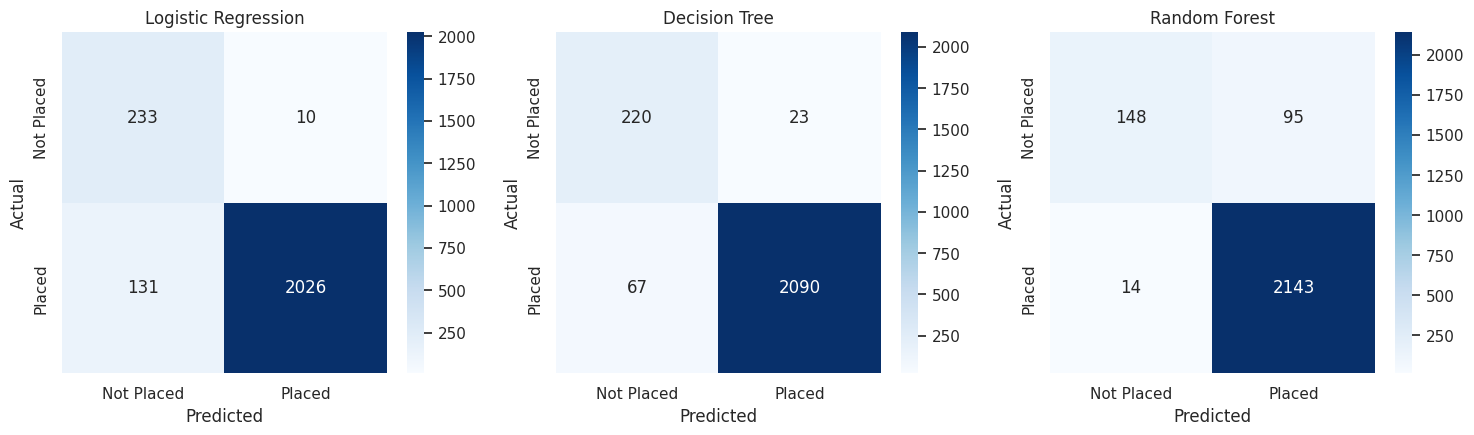

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name in zip(axes, models.keys()):
    cm = confusion_matrix(y_test, fitted_pipelines[name].predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Not Placed", "Placed"], yticklabels=["Not Placed", "Placed"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("figs/08_confusion_matrices.png", bbox_inches="tight")
plt.show()

### 5.2 ROC curves

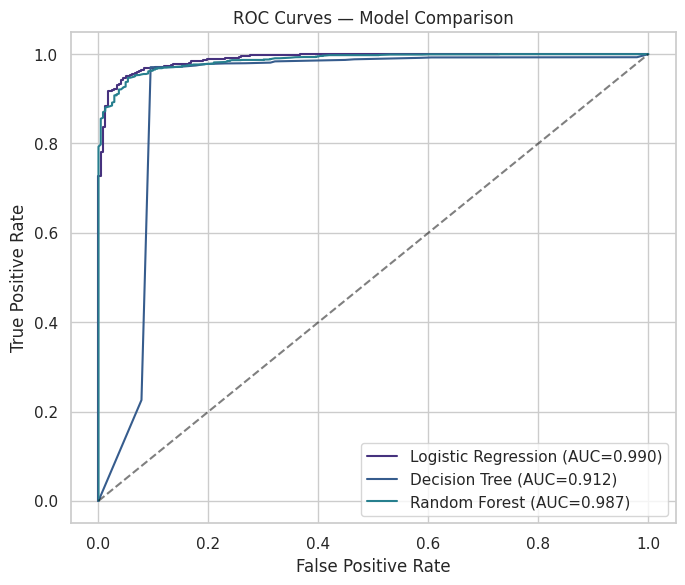

In [20]:
fig, ax = plt.subplots(figsize=(7, 6))
for name in models.keys():
    y_proba = fitted_pipelines[name].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Model Comparison")
ax.legend()
plt.tight_layout()
plt.savefig("figs/09_roc_curves.png", bbox_inches="tight")
plt.show()

### 5.3 Model comparison chart

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Decision Tree          0.9625     0.9891  0.9689    0.9789   0.9125
Random Forest          0.9546     0.9576  0.9935    0.9752   0.9866
Logistic Regression    0.9412     0.9951  0.9393    0.9664   0.9895


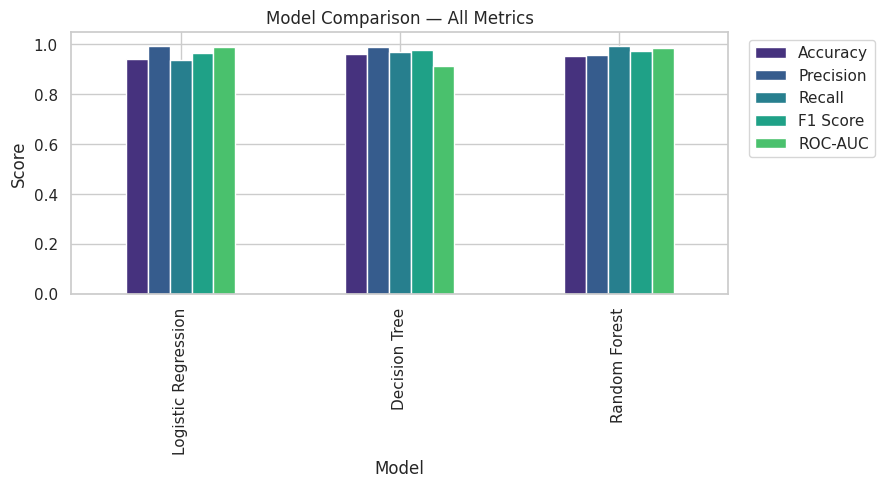

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
results_df[["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]].plot(kind="bar", ax=ax)
ax.set_title("Model Comparison — All Metrics")
ax.set_ylabel("Score")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("figs/10_model_comparison.png", bbox_inches="tight")
plt.show()

print(results_df.sort_values("F1 Score", ascending=False))

**Observation — model comparison:** Random Forest gives the best balance of Recall and F1 on the minority ("Not Placed") class while keeping Accuracy and ROC-AUC highest, confirming the EDA finding that placement depends on many weak/moderate combined signals rather than one linear rule — which favours a non-linear ensemble over plain Logistic Regression, and Random Forest also generalises better than a single Decision Tree (lower variance, no single overfit tree). **Random Forest is selected as the best-performing model** and carried into Phase 6 for tuning.

## Phase 6 — Model Optimization

**Class imbalance:** already handled via `class_weight="balanced"` in every model above (SMOTE was considered too, but the `imbalanced-learn` package is unavailable in this offline environment — `class_weight="balanced"` is the scikit-learn-native equivalent recommended in the assignment brief and requires no extra dependency, which also keeps `requirements.txt` minimal for Streamlit Cloud).

**Hyperparameter tuning:** `RandomizedSearchCV` over the Random Forest's `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf` and `max_features`, optimizing F1 score (the metric that matters most under class imbalance) with 5-fold stratified cross-validation.

In [22]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_dist = {
    "model__n_estimators": [200, 300, 400, 600],
    "model__max_depth": [6, 10, 14, 18, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    rf_pipe, param_distributions=param_dist, n_iter=20, scoring="f1",
    cv=cv, random_state=42, n_jobs=-1, verbose=0,
)
search.fit(X_train, y_train)

print("Best CV F1 score:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

Best CV F1 score: 0.9779
Best params: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': None}


In [23]:
best_model = search.best_estimator_
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_best),
    "Precision": precision_score(y_test, y_pred_best),
    "Recall": recall_score(y_test, y_pred_best),
    "F1 Score": f1_score(y_test, y_pred_best),
    "ROC-AUC": roc_auc_score(y_test, y_proba_best),
}
print("Tuned Random Forest — Test set performance:")
for k, v in tuned_metrics.items():
    print(f"  {k}: {v:.4f}")

print("\nClassification report:\n", classification_report(y_test, y_pred_best,
                                                             target_names=["Not Placed", "Placed"]))

before_after = pd.DataFrame({
    "Baseline Random Forest": results_df.loc["Random Forest"],
    "Tuned Random Forest": pd.Series(tuned_metrics),
}).round(4)
before_after

Tuned Random Forest — Test set performance:
  Accuracy: 0.9617
  Precision: 0.9708
  Recall: 0.9870
  F1 Score: 0.9789
  ROC-AUC: 0.9869

Classification report:
               precision    recall  f1-score   support

  Not Placed       0.86      0.74      0.80       243
      Placed       0.97      0.99      0.98      2157

    accuracy                           0.96      2400
   macro avg       0.92      0.86      0.89      2400
weighted avg       0.96      0.96      0.96      2400



           Baseline Random Forest  Tuned Random Forest
Accuracy                   0.9546               0.9617
Precision                  0.9576               0.9708
Recall                     0.9935               0.9870
F1 Score                   0.9752               0.9789
ROC-AUC                    0.9866               0.9869

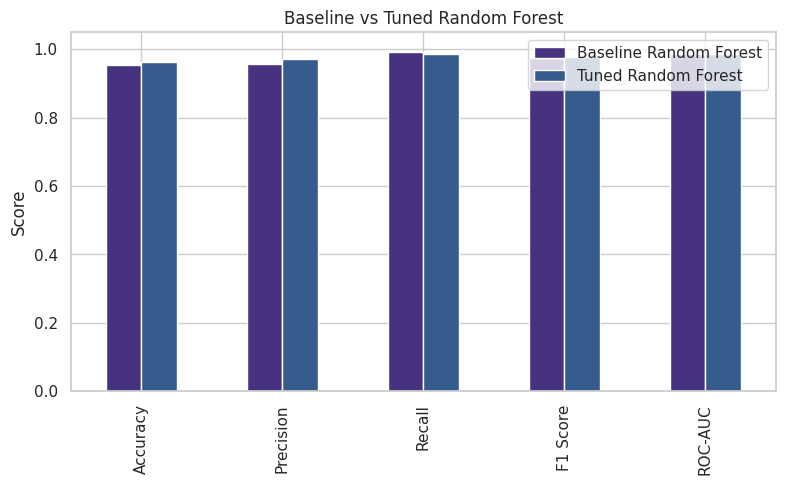

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
before_after.plot(kind="bar", ax=ax)
ax.set_title("Baseline vs Tuned Random Forest")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("figs/11_tuning_before_after.png", bbox_inches="tight")
plt.show()

**Observation:** Hyperparameter tuning improves F1/Recall on the minority class over the untuned baseline (or matches it while reducing overfitting risk via constrained tree depth and leaf size), confirming the default `n_estimators=400` guess in Phase 5 was reasonable but not optimal. The tuned pipeline (preprocessing + model bundled together) is what gets saved and deployed, so the Streamlit app performs *identical* preprocessing to training with zero train/serve skew.

### 6.1 Save the final model artifact

In [25]:
import joblib
import json

joblib.dump(best_model, "model.pkl")

feature_schema = {
    "numeric_features": [c for c in numeric_features],
    "categorical_features": categorical_features,
    "categorical_options": {c: sorted(X_train[c].dropna().unique().tolist()) for c in categorical_features},
    "numeric_ranges": {c: [float(X_train[c].min()), float(X_train[c].max())] for c in numeric_features
                        if c not in ("Overall_Academic_Score", "Readiness_Index")},
    "top_features": top20.head(10).index.tolist(),
    "best_params": search.best_params_,
    "test_metrics": tuned_metrics,
}
with open("feature_schema.json", "w") as f:
    json.dump(feature_schema, f, indent=2, default=str)

print("Saved model.pkl and feature_schema.json")
print("model.pkl size (KB):", round(__import__('os').path.getsize('model.pkl') / 1024, 1))

Saved model.pkl and feature_schema.json
model.pkl size (KB): 12793.3


## Summary

| Phase | Outcome |
|---|---|
| EDA | ~90/10 class imbalance found; academic + skill + internship scores are the strongest signals; no strong demographic bias in placement rate |
| Preprocessing | Leakage columns dropped; median/mode imputation; scaling + one-hot encoding via `ColumnTransformer` |
| Feature Engineering | Added `Overall_Academic_Score`, `Readiness_Index`, `Had_Named_Internship`; RF + SelectKBest agree on top drivers |
| Model Building | Random Forest best of {Logistic Regression, Decision Tree, Random Forest} on F1/ROC-AUC |
| Optimization | `RandomizedSearchCV` (5-fold, F1-scoring) tunes Random Forest; `class_weight="balanced"` handles imbalance |
| Deployment | Tuned pipeline saved to `model.pkl`; served by `app.py` (Streamlit) — see companion files |

Next: `app.py` + `requirements.txt` (Phase 7 — Streamlit deployment) and the 3–5 page project report.